In [1]:
import os, signal, sys, time

sys.path.append(r'C:\Users\adria\coding\katja\DRL-in-international-economy-ai-economist-')

from ai_economist import foundation

import numpy as np

from utils import plotting

In [2]:
from rllib.env_wrapper import RLlibEnvWrapper


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
c:\Users\adria\anaconda3\envs\ai-economist\lib\site-packages\tensorflow\python\framework\dtypes.py:516: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
c:\Users\adria\anaconda3\envs\ai-economist\lib\site-packages\tensorflow\python\framework\dtypes.py:517: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in

In [3]:
env_config_dict = {
    # Scenario with 2 planners
    "scenario_name": "custom/splitworld_overlay_regional",

        'components': [
        # (1) Building houses
        ('Build', {
            'skill_dist':                   'pareto', 
            'payment_max_skill_multiplier': 3,
            'build_labor':                  10,
            'payment':                      10
        }),
        # (2) Trading collectible resources
        ('ContinuousDoubleAuction', {
            'max_bid_ask':    10,
            'order_labor':    0.25,
            'max_num_orders': 5,
            'order_duration': 50
        }),
        # (3) Movement and resource collection
        ('Gather', {
            'move_labor':    1, #prev 1
            'collect_labor': 1,
            'skill_dist':    'pareto'
        }),
        # (4) Planner

        ("RegionalPeriodicBracketTax", {
            "region": "top",
            "planner_id": "p_top",
            "period": 100,
            "bracket_spacing": "us-federal",
            "usd_scaling": 1000,
            "disable_taxes": False,
        }),
        ("RegionalPeriodicBracketTax", {
            "region": "bottom",
            "planner_id": "p_bottom",
            "period": 100,
            "bracket_spacing": "us-federal",
            "usd_scaling": 1000,
            "disable_taxes": False,
        })

    ],
    

    # Map settings
    "env_layout_file": "map_100x50_water_gaps_3percent_resources.txt",
    "world_size": [100, 50],
    'episode_length': 1000, # Number of timesteps per episode

    'starting_agent_coin': 10,
    'fixed_four_skill_and_loc': False,

    # Agents and planners
    "n_agents": 4,
    "planner_subclasses": ["TopPlanner", "BottomPlanner"],
    #"planner_ids": ["p_top", "p_bottom"],
    #"planner_classes": ["TopPlanner", "BottomPlanner"],

    # Modes
    "multi_action_mode_planner": True,
    'multi_action_mode_agents': True,

    'flatten_observations': True,
    # When Flattening masks, concatenate each action subspace mask into a single array.
    # Note: flatten_masks = True is required for masking action logits in the code below.
    'flatten_masks': True,
    
    # How often to save the dense logs
    'dense_log_frequency': 1
}

In [4]:
env_obj = RLlibEnvWrapper({"env_config_dict": env_config_dict}, verbose=True)

[EnvWrapper] Spaces
[EnvWrapper] Obs (a)   
action_mask    : (55,)
flat           : (136,)
time           : (1,)
world-idx_map  : (2, 11, 11)
world-map      : (7, 11, 11)


[EnvWrapper] Obs (p)
  [p_top]
action_mask    : (308,)
flat           : (86,)
p0             : (8,)
p1             : (8,)
p2             : (8,)
p3             : (8,)
time           : (1,)
world-idx_map  : (2, 50, 50)
world-map      : (6, 50, 50)


  [p_bottom]
action_mask    : (308,)
flat           : (18,)
p0             : (8,)
p1             : (8,)
p2             : (8,)
p3             : (8,)
time           : (1,)
world-idx_map  : (2, 49, 50)
world-map      : (6, 49, 50)


[EnvWrapper] Action (a) MultiDiscrete([ 2 12 12 12 12  5])
[EnvWrapper] Action (p) {'p_top': MultiDiscrete([22 22 22 22 22 22 22 22 22 22 22 22 22 22]), 'p_bottom': MultiDiscrete([22 22 22 22 22 22 22 22 22 22 22 22 22 22])}


- both planners can see everything (no it is just include in num actions due to code structure)
- might changes this down the line 


# debug

In [5]:
flat = env_obj.env._generate_masks(flatten_masks=True)
print(flat["p_top"].shape)
print(flat["p_bottom"].shape)


(308,)
(308,)


In [6]:
# Get raw (unflattened) masks directly from env
raw_masks = env_obj.env._generate_masks(flatten_masks=False)

print("Keys for p_top:")
print(list(raw_masks["p_top"].keys()))
print("Num keys (p_top):", len(raw_masks["p_top"].keys()))
print("Per-key lengths (should be 22):", [len(v) for v in raw_masks["p_top"].values()])

print("\nKeys for p_bottom:")
print(list(raw_masks["p_bottom"].keys()))
print("Num keys (p_bottom):", len(raw_masks["p_bottom"].keys()))
print("Per-key lengths (should be 22):", [len(v) for v in raw_masks["p_bottom"].values()])

print("\nFlattened lengths (sanity):")
print("p_top:", sum(len(v) for v in raw_masks["p_top"].values()))
print("p_bottom:", sum(len(v) for v in raw_masks["p_bottom"].values()))




Keys for p_top:
['RegionalPeriodicBracketTax.TaxIndexBracket_000', 'RegionalPeriodicBracketTax.TaxIndexBracket_009', 'RegionalPeriodicBracketTax.TaxIndexBracket_039', 'RegionalPeriodicBracketTax.TaxIndexBracket_084', 'RegionalPeriodicBracketTax.TaxIndexBracket_160', 'RegionalPeriodicBracketTax.TaxIndexBracket_204', 'RegionalPeriodicBracketTax.TaxIndexBracket_510']
Num keys (p_top): 7
Per-key lengths (should be 22): [21, 21, 21, 21, 21, 21, 21]

Keys for p_bottom:
['RegionalPeriodicBracketTax.TaxIndexBracket_000', 'RegionalPeriodicBracketTax.TaxIndexBracket_009', 'RegionalPeriodicBracketTax.TaxIndexBracket_039', 'RegionalPeriodicBracketTax.TaxIndexBracket_084', 'RegionalPeriodicBracketTax.TaxIndexBracket_160', 'RegionalPeriodicBracketTax.TaxIndexBracket_204', 'RegionalPeriodicBracketTax.TaxIndexBracket_510']
Num keys (p_bottom): 7
Per-key lengths (should be 22): [21, 21, 21, 21, 21, 21, 21]

Flattened lengths (sanity):
p_top: 147
p_bottom: 147


In [7]:
# Raw (unflattened) masks
raw_masks = env_obj.env._generate_masks(flatten_masks=False)

print("Unflattened per-bracket lengths (p_top):", [len(v) for v in raw_masks["p_top"].values()])
print("Unflattened sum (p_top):", sum(len(v) for v in raw_masks["p_top"].values()))

# Flattened masks (what RLlib uses)
flat_masks = env_obj.env._generate_masks(flatten_masks=True)
print("Flattened mask length (p_top):", flat_masks["p_top"].shape)



Unflattened per-bracket lengths (p_top): [21, 21, 21, 21, 21, 21, 21]
Unflattened sum (p_top): 147
Flattened mask length (p_top): (308,)


In [8]:
# 1. Flattened
fm = env_obj.env._generate_masks(flatten_masks=True)["p_top"]
print("Flattened 7x22:\n", fm.reshape(-1, 22))

# 2. Raw
rm = env_obj.env._generate_masks(flatten_masks=False)["p_top"]
rm_matrix = np.vstack(list(rm.values()))
print("\nRaw 7x21:\n", rm_matrix)

# 3. Check split (if length 308)
if len(fm) == 308:
    print("\nTop-tax component:\n", fm[:154].reshape(7,22))
    print("\nBottom-tax component:\n", fm[154:].reshape(7,22))

Flattened 7x22:
 [[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]]

Raw 7x21:
 [[1 

In [9]:
for p in env_obj.env.world.planners:
    print("Planner ID:", repr(p.idx), "type:", type(p.idx))


Planner ID: 'p_top' type: <class 'str'>
Planner ID: 'p_bottom' type: <class 'str'>


In [10]:
import ai_economist
from ai_economist.foundation.components.redistribution import RegionalPeriodicBracketTax
#print(RegionalPeriodicBracketTax.__file__)
print(RegionalPeriodicBracketTax.get_n_actions)


<function RegionalPeriodicBracketTax.get_n_actions at 0x00000182E1FA4AF8>


In [11]:
obs = env_obj.env.reset()
obs['p_top']['action_mask'].shape
obs['p_bottom']['action_mask'].shape

(308,)

## end debug

In [12]:
obs_space_p_top     = env_obj.observation_space_pl["p_top"]
act_space_p_top     = env_obj.action_space_pl["p_top"]

obs_space_p_bottom  = env_obj.observation_space_pl["p_bottom"]
act_space_p_bottom  = env_obj.action_space_pl["p_bottom"]


In [13]:
import ray
from ray.rllib.agents.ppo import PPOTrainer

In [14]:
# Policies
policies = {
    # Mobile agents (shared policy)
    "a": (
        None,
        env_obj.observation_space,   # dict-like space for any mobile agent (e.g., "0")
        env_obj.action_space,
        {}
    ),
    # Top planner
    "p_top": (
        None,
        env_obj.observation_space_pl["p_top"],
        env_obj.action_space_pl["p_top"],
        {}
    ),
    # Bottom planner
    "p_bottom": (
        None,
        env_obj.observation_space_pl["p_bottom"],
        env_obj.action_space_pl["p_bottom"],
        {}
    ),
}

# Mapping: digits -> "a"; exact planner ids -> their own policies
policy_mapping_fun = lambda i: (
    "a" if str(i).isdigit()
    else ("p_top" if i == "p_top" else ("p_bottom" if i == "p_bottom" else "a"))
)

policies_to_train = ["a", "p_top", "p_bottom"]



In [15]:
trainer_config = {
    "multiagent": {
        "policies": policies,
        "policies_to_train": policies_to_train,
        "policy_mapping_fn": policy_mapping_fun,
    }
}

trainer_config.update(
    {
        "num_workers": 0,
        "num_envs_per_worker": 1,
        # Other training parameters
        "train_batch_size":  4000,
        "sgd_minibatch_size": 4000,
        "num_sgd_iter": 1

    }
)

In [16]:
# We also add the "num_envs_per_worker" parameter for the env. wrapper to index the environments.
env_config = {
    "env_config_dict": env_config_dict,
    "num_envs_per_worker": trainer_config.get('num_envs_per_worker'),   
}

trainer_config.update(
    {
        "env_config": env_config        
    }
)

In [17]:
# from ray.rllib.agents.ppo import PPOTrainer
# import ray
# import os

# # Prevent Ray memory monitor crashes
# os.environ["RAY_DISABLE_MEMORY_MONITOR"] = "1"

# # Restart Ray cleanly
# ray.shutdown()
# ray.init(ignore_reinit_error=True)

# trainer_config = {

#     # Environment
#     "env_config": env_config_dict,

#     # ---- Stability fixes ----
#     "num_workers": 0,            # critical for Windows stability
#     "num_gpus": 0,

#     # ---- Framework ----
#     "framework": "tf",

#     # ---- PPO core parameters ----
#     "lr": 5e-5,
#     "gamma": 0.99,
#     "lambda": 0.95,
#     "clip_param": 0.2,

#     # ---- Training batch sizes ----
#     "rollout_fragment_length": 200,
#     "train_batch_size": 4000,
#     "sgd_minibatch_size": 512,
#     "num_sgd_iter": 10,

#     # ---- Model architecture ----
#     "model": {
#         "fcnet_hiddens": [256, 256],
#         "fcnet_activation": "tanh",
#     },

#     # ---- Logging / debugging ----
#     "log_level": "WARN",

# }

# trainer = PPOTrainer(
#     env=RLlibEnvWrapper,
#     config=trainer_config
# )

In [18]:
# NUM_ITERS = 200

# for iteration in range(NUM_ITERS):

#     result = trainer.train()

#     print(
#         f"Iter {iteration} | "
#         f"Reward: {result['episode_reward_mean']:.2f} | "
#         f"Episodes: {result['episodes_total']}"
#     )

In [19]:
# config = {
#     "env": RLlibEnvWrapper,
#     "env_config": {"env_config_dict": env_config_dict},
#     "num_envs_per_worker": trainer_config.get("num_envs_per_worker", 1),
# }

In [20]:
# import ray
# ray.shutdown()
# ray.init()

In [21]:
ray.init(webui_host="127.0.0.1")

2026-03-13 15:29:29,660	INFO resource_spec.py:212 -- Starting Ray with 5.37 GiB memory available for workers and up to 2.7 GiB for objects. You can adjust these settings with ray.init(memory=<bytes>, object_store_memory=<bytes>).


2026-03-13 15:29:30,134	INFO services.py:1165 -- View the Ray dashboard at 127.0.0.1:8265


{'node_ip_address': '192.168.1.108',
 'raylet_ip_address': '192.168.1.108',
 'redis_address': '192.168.1.108:6379',
 'object_store_address': 'tcp://127.0.0.1:65456',
 'raylet_socket_name': 'tcp://127.0.0.1:64726',
 'webui_url': '127.0.0.1:8265',
 'session_dir': 'C:\\Users\\adria\\AppData\\Local\\Temp\\ray\\session_2026-03-13_15-29-29_652238_23128'}

In [22]:
trainer = PPOTrainer(
    env=RLlibEnvWrapper,
    config=trainer_config,
    )

2026-03-13 15:29:35,366	ERROR syncer.py:46 -- Log sync requires rsync to be installed.
2026-03-13 15:29:35,369	INFO trainer.py:585 -- Tip: set framework=tfe or the --eager flag to enable TensorFlow eager execution
2026-03-13 15:29:35,369	INFO trainer.py:612 -- Current log_level is WARN. For more information, set 'log_level': 'INFO' / 'DEBUG' or use the -v and -vv flags.
2026-03-13 15:30:35,625	INFO trainable.py:181 -- _setup took 60.258 seconds. If your trainable is slow to initialize, consider setting reuse_actors=True to reduce actor creation overheads.


In [23]:
NUM_ITERS = 10
for iteration in range(NUM_ITERS):
    print(f'********** Iter : {iteration} **********')
    result = trainer.train()
    print(f'''episode_reward_mean: {result.get('episode_reward_mean')}''')

********** Iter : 0 **********
episode_reward_mean: -374.47957051324374
********** Iter : 1 **********
episode_reward_mean: -403.3481319756154
********** Iter : 2 **********
episode_reward_mean: -388.23688147462354
********** Iter : 3 **********
episode_reward_mean: -391.1456030951021
********** Iter : 4 **********
episode_reward_mean: -390.21864819099466
********** Iter : 5 **********
episode_reward_mean: -394.00664294233223
********** Iter : 6 **********
episode_reward_mean: -389.6814401903319
********** Iter : 7 **********
episode_reward_mean: -382.3485055417021
********** Iter : 8 **********
episode_reward_mean: -373.6031498135462
********** Iter : 9 **********
episode_reward_mean: -369.8227841375061


In [ ]:
# def generate_rollout_from_current_trainer_policy(
#     trainer, 
#     env_obj,
#     num_dense_logs=1
# ):
#     dense_logs = {}
#     for idx in range(num_dense_logs):
#         # Set initial states
#         agent_states = {}
#         for agent_idx in range(env_obj.env.n_agents):
#             agent_states[str(agent_idx)] = trainer.get_policy("a").get_initial_state()
#         planner_states = trainer.get_policy("p").get_initial_state()   

#         # Play out the episode
#         steps = 0
#         obs = env_obj.reset(force_dense_logging=True)
#         for t in range(env_obj.env.episode_length):
#             actions = {}
#             for agent_idx in range(env_obj.env.n_agents):
#                 # Use the trainer object directly to sample actions for each agent
#                 actions[str(agent_idx)] = trainer.compute_action(
#                     obs[str(agent_idx)], 
#                     agent_states[str(agent_idx)], 
#                     policy_id="a",
#                     full_fetch=False
#                 )
            
#             # Action sampling for the planner
#             actions["p"] = trainer.compute_action(
#                 obs['p'], 
#                 planner_states, 
#                 policy_id='p',
#                 full_fetch=False
#             )
#             steps += 1
#             obs, rew, done, info = env_obj.step(actions)        
#             if done['__all__']:
#                 break

#         #print("Episode length:", steps)
#         import copy
#         dense_logs[idx] = copy.deepcopy(env_obj.env.dense_log) #new

        




#     return dense_logs

In [ ]:
# dense_logs = generate_rollout_from_current_trainer_policy(
#     trainer, 
#     env_obj,
#     num_dense_logs=10
# )

AttributeError: 'NoneType' object has no attribute 'get_initial_state'

In [ ]:
# def generate_rollout_with_planner_actions(
#     trainer,
#     env_obj,
#     num_dense_logs=10
# ):
#     dense_logs = {}

#     for idx in range(num_dense_logs):
#         # Reset RNN states
#         agent_states = {
#             str(agent_idx): trainer.get_policy("a").get_initial_state()
#             for agent_idx in range(env_obj.env.n_agents)
#         }
#         planner_states = trainer.get_policy("p").get_initial_state()


#         obs = env_obj.reset(force_dense_logging=True)

#         planner_actions_log = []

#         for t in range(env_obj.env.episode_length):

#             # Collect agent actions
#             actions = {}
#             for agent_idx in range(env_obj.env.n_agents):
#                 act = trainer.compute_action(
#                     obs[str(agent_idx)],
#                     agent_states[str(agent_idx)],
#                     policy_id="a",
#                     full_fetch=False
#                 )
#                 actions[str(agent_idx)] = act

#             # Collect the planner action
#             p_act = trainer.compute_action(
#                 obs["p"],
#                 planner_states,
#                 policy_id="p",
#                 full_fetch=False
#             )
#             actions["p"] = p_act

#             planner_actions_log.append(p_act)

#             obs, rew, done, info = env_obj.step(actions)
#             if done["__all__"]:
#                 break

#         # Copy Foundation's dense log and extend with planner actions
#         dense_logs[idx] = dict(env_obj.env.dense_log)
#         dense_logs[idx]["planner_actions"] = np.array(planner_actions_log)

#     return dense_logs

In [ ]:
# dense_logs = generate_rollout_with_planner_actions(
#     trainer,
#     env_obj,
#     num_dense_logs=10
# )

AttributeError: 'NoneType' object has no attribute 'get_initial_state'

In [34]:
def generate_rollout_with_planner_actions(
    trainer,
    env_obj,
    num_dense_logs=10
):
    dense_logs = {}

    for idx in range(num_dense_logs):

        # --- Reset RNN / internal policy states ---
        agent_states = {
            str(agent_idx): trainer.get_policy("a").get_initial_state()
            for agent_idx in range(env_obj.env.n_agents)
        }

        p_top_states = trainer.get_policy("p_top").get_initial_state()
        p_bottom_states = trainer.get_policy("p_bottom").get_initial_state()

        # --- Reset env (enable dense logging) ---
        obs = env_obj.reset(force_dense_logging=True)

        planner_actions_log = {"p_top": [], "p_bottom": []}

        for t in range(env_obj.env.episode_length):

            actions = {}

            # --- Agent actions ---
            for agent_idx in range(env_obj.env.n_agents):
                act = trainer.compute_action(
                    obs[str(agent_idx)],
                    agent_states[str(agent_idx)],
                    policy_id="a",
                    full_fetch=False
                )
                actions[str(agent_idx)] = act

            # --- Planner p_top ---
            act_top = trainer.compute_action(
                obs["p_top"],
                p_top_states,
                policy_id="p_top",
                full_fetch=False
            )
            actions["p_top"] = act_top
            planner_actions_log["p_top"].append(act_top)

            # --- Planner p_bottom ---
            act_bottom = trainer.compute_action(
                obs["p_bottom"],
                p_bottom_states,
                policy_id="p_bottom",
                full_fetch=False
            )
            actions["p_bottom"] = act_bottom
            planner_actions_log["p_bottom"].append(act_bottom)

            # --- Step environment ---
            obs, rew, done, info = env_obj.step(actions)
            if done["__all__"]:
                break

        # Store dense logs + planner action traces
        dense_logs[idx] = dict(env_obj.env.dense_log)
        dense_logs[idx]["planner_actions"] = planner_actions_log

    return dense_logs

In [35]:
dense_logs = generate_rollout_with_planner_actions(
    trainer,
    env_obj,
    num_dense_logs=10
)

KeyError: '4'

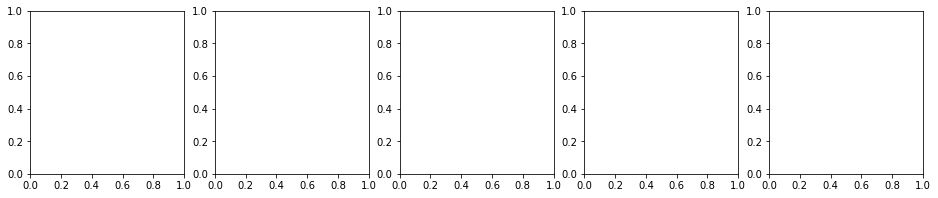

In [36]:
plotting.breakdown(dense_logs[0])   # agent actions (unchanged)
dense_logs[0]["planner_actions"]    # <-- your new planner actions

In [ ]:
plotting.breakdown(dense_logs[9])   # agent actions (unchanged)
dense_logs[9]["planner_actions"]    # <-- your new planner actions